# Example #1: Governing Law clause analysis

_This notebook builds on the quickstart guide. If you're new to Python/Jupyter and haven't read the quickstart yet, we recommend starting there._

**What is this?**
- This notebook features a basic analysis of Governing Law clauses (standard ID `5e59453aaa9255c4`)
  
**Prerequisites**
- Run `pip install requests pandas seaborn matplotlib numpy`
  - This will install `requests`, `pandas`, `seaborn`, `matplotlib`, and `numpy` (if not already installed)
- Obtain an API key from [pandects.org](https://pandects.org) and export it as `PANDECTS_API_KEY`

## Imports and setup

In [211]:
import os
import re
import time
from collections import Counter
import xml.dom.minidom
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from matplotlib.ticker import MultipleLocator

pd.set_option('display.max_rows', None)
sns.set_theme(style="whitegrid", context="notebook")

In [212]:
# Configuration
API_BASE_URL = 'http://127.0.0.1:5113'  #"https://api.pandects.org"
API_KEY = 'pdcts_98184ac91ee449cd915a6ed7f6d7049a15f5447da74942ed9cdeff3f2a9d70fa'  #os.getenv("PANDECTS_API_KEY")

if not API_KEY:
    raise RuntimeError(
        "Missing PANDECTS_API_KEY. Export your key (starts with pdcts_) and re-run this cell."
    )

session = requests.Session()
session.headers.update({"Accept": "application/json", "X-API-Key": API_KEY})


## Governing Law analysis

### Download
Paginate through all matching sections for clause type `5e59453aaa9255c4`, which is the taxonomy ID for Governing Law clauses.

In [213]:
CLAUSE_TYPE_ID = "5e59453aaa9255c4"  # Governing Law taxonomy ID

page = 1
page_size = 100
sections = []

start_time = time.time()
progress_every = 10

while True:
    r = session.get(
        f"{API_BASE_URL}/v1/sections",
        params={
            "standard_id": CLAUSE_TYPE_ID,
            "page": page,
            "page_size": page_size,
            "metadata": ["deal_type"],  # Request additional metadata fields
        },
        timeout=30,
    )
    r.raise_for_status()
    payload = r.json()

    batch = payload["results"]
    sections.extend(batch)

    current_page = payload["page"]
    total_pages = payload["total_pages"]
    if current_page % progress_every == 0 or not payload.get("has_next"):
        elapsed = time.time() - start_time
        print(
            f"Progress: page {current_page}/{total_pages} | sections={len(sections)} | elapsed={elapsed:.1f}s"
        )

    if not payload.get("has_next"):
        break
    page = payload["next_num"]

    time.sleep(1)  # API limit: 300 requests per minute

elapsed_total = time.time() - start_time
print(f"Returned sections: {len(sections)}")
print(f"Access tier: {payload.get('access', {}).get('tier')}")
print(f"Total download time: {elapsed_total:.1f}s")

if not sections:
    raise RuntimeError(f"No sections found for standard_id={CLAUSE_TYPE_ID}")


Progress: page 10/11 | sections=100 | elapsed=11.4s
Progress: page 20/21 | sections=200 | elapsed=22.3s
Progress: page 30/31 | sections=300 | elapsed=33.2s
Progress: page 40/41 | sections=400 | elapsed=44.2s
Progress: page 50/51 | sections=500 | elapsed=55.2s
Progress: page 60/61 | sections=600 | elapsed=66.1s
Progress: page 70/71 | sections=700 | elapsed=77.1s
Progress: page 80/81 | sections=800 | elapsed=87.9s
Progress: page 90/91 | sections=900 | elapsed=98.8s
Progress: page 100/101 | sections=1000 | elapsed=109.7s
Progress: page 110/111 | sections=1100 | elapsed=120.5s
Progress: page 120/121 | sections=1200 | elapsed=131.3s
Progress: page 130/131 | sections=1300 | elapsed=142.1s
Progress: page 140/141 | sections=1400 | elapsed=153.1s
Progress: page 150/151 | sections=1500 | elapsed=164.0s
Progress: page 160/161 | sections=1600 | elapsed=174.9s
Progress: page 170/171 | sections=1700 | elapsed=185.7s
Progress: page 180/181 | sections=1800 | elapsed=196.7s
Progress: page 190/191 | sec

In [245]:
df = pd.DataFrame(sections)
df.head(1)

,acquirer,agreement_uuid,article_title,id,metadata,section_title,section_uuid,standard_id,target,verified,xml,year
0,CINTAS CORPORATION,8f3084d0-f42d-5bb7-9f6a-a4a51e55a1b4,Article VIII General Provisions,c79ddd26-7629-5ee1-844b-05553214bd18,{'deal_type': 'merger'},Section 8.9 Governing Law.,c79ddd26-7629-5ee1-844b-05553214bd18,[5e59453aaa9255c4],UNIFIRST CORPORATION,False,\n <text>This Agreement and all Proceed...,2026


In [246]:
# Expand requested metadata into top-level columns
df = df.join(pd.json_normalize(df["metadata"]))

In [247]:
# Map deal type codes to display labels
deal_type_map = {
    "merger": "Merger",
    "stock_acquisition": "Stock acquisition",
    "asset_acquisition": "Asset acquisition",
    "membership_interest_purchase": "Membership interest",
    "tender_offer": "Tender offer",
}

df['deal_type'] = df['deal_type'].map(deal_type_map)


In [248]:
df.head()

,acquirer,agreement_uuid,article_title,id,metadata,section_title,section_uuid,standard_id,target,verified,xml,year,deal_type
0,CINTAS CORPORATION,8f3084d0-f42d-5bb7-9f6a-a4a51e55a1b4,Article VIII General Provisions,c79ddd26-7629-5ee1-844b-05553214bd18,{'deal_type': 'merger'},Section 8.9 Governing Law.,c79ddd26-7629-5ee1-844b-05553214bd18,[5e59453aaa9255c4],UNIFIRST CORPORATION,False,\n <text>This Agreement and all Proceed...,2026,Merger
1,Ondas Inc.,93cc5d8e-14c1-56bb-9b69-e4c097df0208,ARTICLE X GENERAL PROVISIONS,32f7a5d9-a0a2-5eaf-9c52-f152135e2d85,{'deal_type': 'merger'},Section 10.08 Governing Law.,32f7a5d9-a0a2-5eaf-9c52-f152135e2d85,[5e59453aaa9255c4],"Mistral, Inc.",False,\n <text>This Agreement is governed by ...,2026,Merger
2,Aureus Greenway Holdings Inc.,3a8e1180-d3a2-5d6f-a0ba-02ce403a7182,Article VIII MISCELLANEOUS,1eb40b3b-4a58-52db-9314-449e6d091b99,{'deal_type': 'merger'},Section 8.4 Governing Law.,1eb40b3b-4a58-52db-9314-449e6d091b99,[5e59453aaa9255c4],Autonomous Power Corporation,False,\n <text>All matters arising out of or ...,2026,Merger
3,Servier Pharmaceuticals LLC,9a7b5f44-58bd-506e-9237-67da795119dd,ARTICLE X GENERAL PROVISIONS,79579a7a-2c3d-5407-9655-78fe9fb66d6a,{'deal_type': 'tender_offer'},SECTION 10.06 Governing Law.,79579a7a-2c3d-5407-9655-78fe9fb66d6a,[5e59453aaa9255c4],"Day One Biopharmaceuticals, Inc.",False,\n <text>This Agreement shall be govern...,2026,Tender offer
4,Bleichroeder Acquisition 2 France,65f07e0b-8a5b-53e9-b642-d713d97ce808,Article XI. GENERAL PROVISIONS,78c5eee7-1cf1-5c38-b0db-9ab35627e8ab,{'deal_type': 'merger'},Section 11.9 Governing Law; Dispute Resolution...,78c5eee7-1cf1-5c38-b0db-9ab35627e8ab,[5e59453aaa9255c4],PASQAL HOLDING SAS,False,\n <text>(a) Governing Law. Other than ...,2026,Merger


### Basic sample overview

#### 1. Simple counts

In [249]:
print("Top acquirers:")
for name, n in Counter(s["acquirer"] for s in sections).most_common(5):
    print(f"- {name} ({n})")

print("\nTop years:")
for year, n in Counter(s["year"] for s in sections).most_common(5):
    print(f"- {year} ({n})")


Top acquirers:
- Oracle Corp. (18)
- International Business Machines Corp. (13)
- Nuance Communications, Inc. (12)
- Abbott Laboratories (11)
- Thoma Bravo LLC (11)

Top years:
- 2007 (415)
- 2017 (409)
- 2018 (382)
- 2015 (380)
- 2016 (367)


#### 2. Number of deals by year

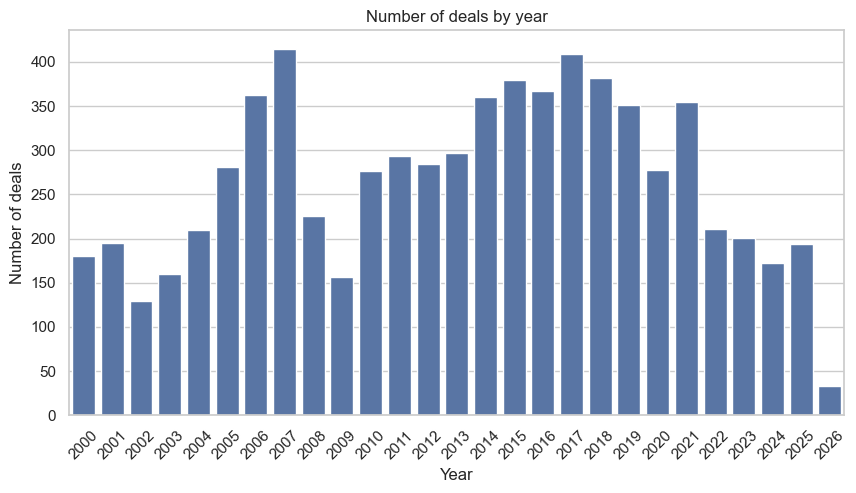

In [250]:
counts = df.groupby("year").size().reset_index(name="n_deals").sort_values("year")

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=counts, x=counts["year"].astype(int).astype(str), y="n_deals")
ax.set_xlabel("Year")
ax.set_ylabel("Number of deals")
ax.set_title("Number of deals by year")
_ = plt.xticks(rotation=45)


#### 3. Number of deals by year (stacked by deal type)

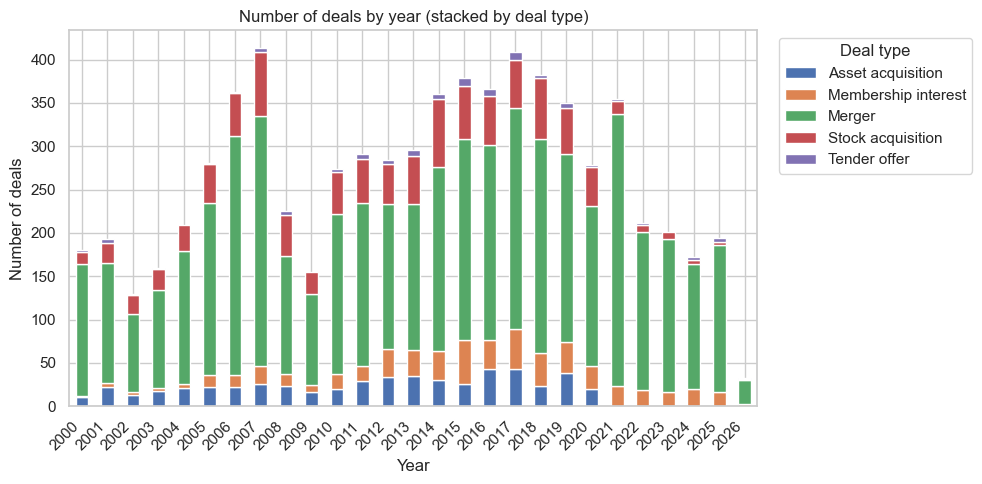

In [251]:
counts = (
    df.groupby(["year", "deal_type"])
      .size()
      .reset_index(name="n_deals")
)

wide = (
    counts.pivot(index="year", columns="deal_type", values="n_deals")
          .fillna(0)
          .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
wide.plot(kind="bar", stacked=True, ax=ax)

ax.set_xlabel("Year")
ax.set_ylabel("Number of deals")
ax.set_title("Number of deals by year (stacked by deal type)")
ax.set_xticklabels(wide.index.astype(int).astype(str), rotation=45, ha="right")

ax.legend(title="Deal type", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


### See what states dominate governing law clauses

#### Prep #1
Map clauses to jurisdictions

In [252]:
us_states = [
    "Alabama",
    "Alaska",
    "Arizona",
    "Arkansas",
    "California",
    "Colorado",
    "Connecticut",
    "Delaware",
    "Florida",
    "Georgia",
    "Hawaii",
    "Idaho",
    "Illinois",
    "Indiana",
    "Iowa",
    "Kansas",
    "Kentucky",
    "Louisiana",
    "Maine",
    "Maryland",
    "Massachusetts",
    "Michigan",
    "Minnesota",
    "Mississippi",
    "Missouri",
    "Montana",
    "Nebraska",
    "Nevada",
    "New Hampshire",
    "New Jersey",
    "New Mexico",
    "New York",
    "North Carolina",
    "North Dakota",
    "Ohio",
    "Oklahoma",
    "Oregon",
    "Pennsylvania",
    "Rhode Island",
    "South Carolina",
    "South Dakota",
    "Tennessee",
    "Texas",
    "Utah",
    "Vermont",
    "Virginia",
    "Washington",
    "West Virginia",
    "Wisconsin",
    "Wyoming",
]

foreign_countries = [
    "Australia", "Australian",
    "Austria", "Austrian",
    "Belgium", "Belgian",
    "Canada", "Canadian",
    "Chile", "Chilean",
    "Croatia", "Croatian",
    "Cyprus", "Cypriot",
    "Czechia", "Czech",
    "Denmark", "Danish",
    "Estonia", "Estonian",
    "Finland", "Finnish",
    "France", "French",
    "Germany", "German",
    "Greece", "Greek",
    "Hong Kong", "Hong Kong",
    "Hungary", "Hungarian",
    "Iceland", "Icelandic",
    "Ireland", "Irish",
    "Israel", "Israeli",
    "Italy", "Italian",
    "Japan", "Japanese",
    "Latvia", "Latvian",
    "Liechtenstein", "Liechtenstein",
    "Lithuania", "Lithuanian",
    "Luxembourg", "Luxembourgish",
    "Malta", "Maltese",
    "Netherlands", "Dutch",
    "New Zealand", "New Zealand",
    "Norway", "Norwegian",
    "Poland", "Polish",
    "Portugal", "Portuguese",
    "Romania", "Romanian",
    "Singapore", "Singaporean",
    "Slovakia", "Slovak",
    "Slovenia", "Slovenian",
    "South Korea", "South Korean",
    "Spain", "Spanish",
    "Sweden", "Swedish",
    "Switzerland", "Swiss",
    "Taiwan", "Taiwanese",
    "United Arab Emirates", "Emirati",
    "United Kingdom", "British",
    "Andorra", "Andorran",
    "Monaco", "Monegasque",
    "San Marino", "Sammarinese",
    "Qatar", "Qatari",
    "Saudi Arabia", "Saudi",
    "Kuwait", "Kuwaiti",
    "Bahrain", "Bahraini",
]

states = us_states + foreign_countries

_state_re = re.compile(
    r"\b(?:"
    + "|".join(re.escape(s) for s in sorted(states, key=len, reverse=True))
    + r")\b",
    flags=re.IGNORECASE,
)
_state_canon = {s.lower(): s for s in states}

hits = df["xml"].fillna("").str.findall(_state_re)

def canon_unique(lst):
    if not lst:
        return ["N/A"]
        
    seen = set()
    out = []
    for h in lst:
        k = h.lower()
        if k not in seen:
            seen.add(k)
            out.append(_state_canon[k])
    return sorted(out)

df["states"] = hits.map(canon_unique)

In [253]:
df['states'].value_counts()

states
[Delaware]                                                  3564
[New York]                                                   874
[Delaware, New York]                                         610
[Texas]                                                      232
[California]                                                 132
[Maryland]                                                   126
[Canada]                                                      79
[Pennsylvania]                                                75
[Massachusetts]                                               54
[California, Delaware]                                        48
[Ohio]                                                        42
[N/A]                                                         42
[Florida]                                                     42
[Delaware, Maryland]                                          40
[Nevada]                                                      38
[Illinois]        

In [254]:
df["mentions_delaware"] = df["states"].apply(lambda xs: "Delaware" in xs)
df["mentions_new_york"] = df["states"].apply(lambda xs: "New York" in xs)

df["only_delaware"] = df["states"].apply(lambda xs: xs == ['Delaware'])
df["only_new_york"] = df["states"].apply(lambda xs: xs == ['New York'])

#### Prep #2
Filter down to sections that are Governing Law clauses only, rather than Governing Law + Forum Selection + ..., or else that have selected only a single state

In [255]:
r = session.get(f"{API_BASE_URL}/v1/taxonomy", timeout=30)
r.raise_for_status()
taxonomy = r.json()

In [256]:
id_to_full_path = {}
id_to_leaf = {}

l1_items = taxonomy.items() if isinstance(taxonomy, dict) else taxonomy  # dict or list[tuple]

for l1_title, l1_node in l1_items:
    id_to_full_path[l1_node["id"]] = l1_title
    id_to_leaf[l1_node["id"]] = l1_title

    for l2_title, l2_node in (l1_node.get("children") or {}).items():
        full_l2 = f"{l1_title} > {l2_title}"
        id_to_full_path[l2_node["id"]] = full_l2
        id_to_leaf[l2_node["id"]] = l2_title

        for l3_title, l3_node in (l2_node.get("children") or {}).items():
            full_l3 = f"{l1_title} > {l2_title} > {l3_title}"
            id_to_full_path[l3_node["id"]] = full_l3
            id_to_leaf[l3_node["id"]] = l3_title

df["standard_id_text"] = df["standard_id"].apply(
    lambda x: (
        None if x is None else
        (" | ".join(id_to_leaf.get(i, str(i)) for i in x) if isinstance(x, list)
         else id_to_leaf.get(x, str(x)))
    )
)

df["standard_id_full_text"] = df["standard_id"].apply(
    lambda x: (
        None if x is None else
        (" | ".join(id_to_full_path.get(i, str(i)) for i in x) if isinstance(x, list)
         else id_to_full_path.get(x, str(x)))
    )
)

In [257]:
df["standard_id_text"].value_counts().head(9)

standard_id_text
Governing Law                                                                                                                                      4616
Governing Law | Forum Selection / Venue; Submission to Jurisdiction                                                                                1308
Governing Law | Forum Selection / Venue; Submission to Jurisdiction | Waiver of Jury Trial                                                          907
Governing Law | Waiver of Jury Trial                                                                                                                109
Governing Law | Forum Selection / Venue; Submission to Jurisdiction | Waiver of Jury Trial | Specific Performance; Injunction; Equitable Relief      94
Governing Law | Forum Selection / Venue; Submission to Jurisdiction | Specific Performance; Injunction; Equitable Relief                             32
Governing Law | Waiver of Jury Trial | Forum Selection / Venue; Submiss

In [260]:
df["eligible"] = df[["standard_id", "states"]].apply(lambda x: x["standard_id"] == ["5e59453aaa9255c4"] or
                                                     ('5e59453aaa9255c4' in x["standard_id"] and len(x["states"])==1), axis=1)

df["gov_law_only"] = df[["standard_id", "states"]].apply(lambda x: x["standard_id"] == ["5e59453aaa9255c4"], axis=1)

pdf[df["eligible"]].shape

(6387, 22)

In [261]:
df = df[df["eligible"]]

In [262]:
def wilson_ci(k, n, z=1.96):
    k = np.asarray(k, dtype=float)
    n = np.asarray(n, dtype=float)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = (z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n)) / denom
    lo = np.clip(center - half, 0, 1)
    hi = np.clip(center + half, 0, 1)
    return lo, hi

#### 1. What kinds of deals have multiple states in their governing law clauses?

In [263]:
df['states'].value_counts()

states
[Delaware]                                3564
[New York]                                 874
[Delaware, New York]                       252
[Texas]                                    232
[California]                               132
[Maryland]                                 126
[Canada]                                    79
[Pennsylvania]                              75
[Massachusetts]                             54
[N/A]                                       42
[Florida]                                   42
[Ohio]                                      42
[Nevada]                                    38
[Illinois]                                  36
[Virginia]                                  34
[California, Delaware]                      28
[North Carolina]                            25
[Washington]                                24
[New Jersey]                                23
[Tennessee]                                 22
[Delaware, Maryland]                        20
[India

In [264]:
df['mult'] = df['states'].apply(lambda x: len(x) >= 2)

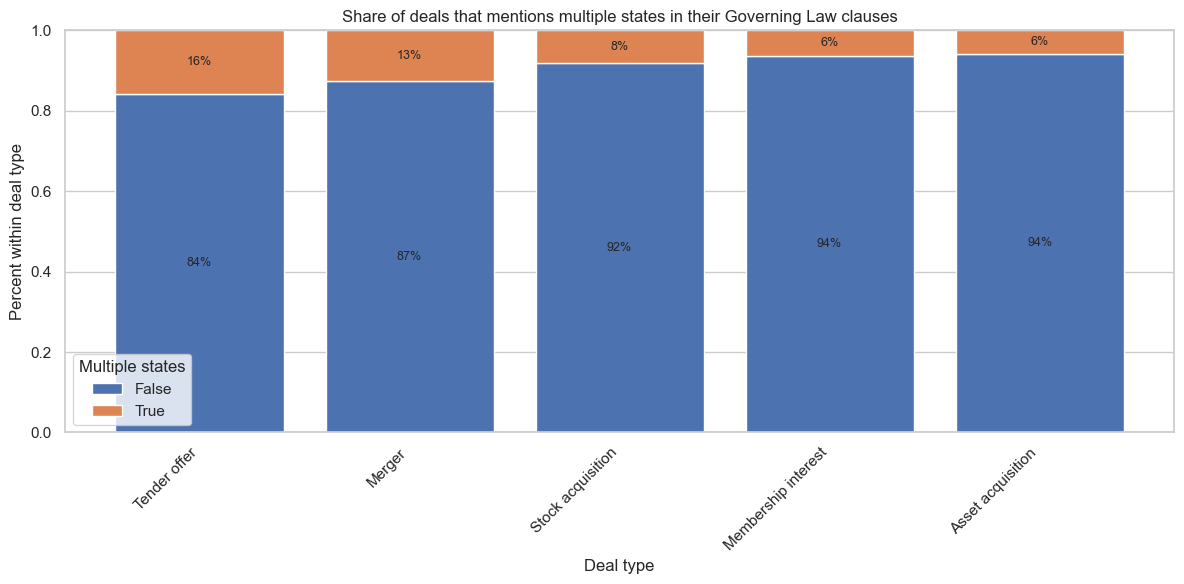

In [265]:
# Keep only usable rows
plot_df = df.dropna(subset=["mult", "deal_type"]).copy()

# Ensure mult is numeric 0/1
plot_df["mult"] = pd.to_numeric(plot_df["mult"], errors="coerce")
plot_df = plot_df[plot_df["mult"].isin([0, 1])]

counts = (
    plot_df.groupby(["deal_type", "mult"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[0, 1], fill_value=0)
)

shares = counts.div(counts.sum(axis=1), axis=0).sort_values(by=1, ascending=False)

sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(shares))
bars0 = ax.bar(x, shares[0], label="False")
bars1 = ax.bar(x, shares[1], bottom=shares[0], label="True")

ax.set_xticks(list(x))
ax.set_xticklabels(shares.index, rotation=45, ha="right")
ax.set_ylim(0, 1)
ax.set_xlabel("Deal type")
ax.set_ylabel("Percent within deal type")
ax.set_title("Share of deals that mentions multiple states in their Governing Law clauses")
ax.legend(title="Multiple states")

# Optional labels inside bars
for i, (v0, v1) in enumerate(zip(shares[0], shares[1])):
    if v0 > 0.05:
        ax.text(i, v0 / 2, f"{v0:.0%}", ha="center", va="center", fontsize=9)
    if v1 > 0.05:
        ax.text(i, v0 + v1 / 2, f"{v1:.0%}", ha="center", va="center", fontsize=9)

plt.tight_layout()
plt.show()

In [266]:
mult = df[df['mult']]
mult.shape

(697, 23)

In [267]:
mult['states'].value_counts()

states
[Delaware, New York]                      252
[California, Delaware]                     28
[Delaware, Maryland]                       20
[British, Canada]                          14
[Delaware, Texas]                          11
[Delaware, Florida]                        11
[Delaware, Illinois]                       10
[Nevada, New York]                         10
[Delaware, Nevada]                          9
[New York, Texas]                           8
[Delaware, Ohio]                            8
[Delaware, Washington]                      8
[Maryland, New York]                        8
[British, Delaware]                         8
[Delaware, Pennsylvania]                    7
[Delaware, Minnesota]                       7
[Delaware, Israel]                          7
[Canada, New York]                          6
[California, New York]                      6
[Delaware, Michigan]                        5
[British, Canada, Delaware]                 5
[Delaware, Luxembourg]     

In [268]:
df['has_debt'] = df['xml'].str.lower().str.contains('debt')
df['has_financing'] = df['xml'].str.lower().str.contains('financ')

In [269]:
ny_de = df[df['mentions_new_york'] & df['mentions_delaware']].shape[0]
ny_de_debt = df[df['has_debt'] & df['mult'] & df['mentions_new_york'] & df['mentions_delaware']].shape[0]
ny_de_financing = df[df['has_financing'] & df['mult'] & df['mentions_new_york'] & df['mentions_delaware']].shape[0]
ny_de_both = df[(df['has_financing'] | df['has_debt']) & df['mult'] & df['mentions_new_york'] & df['mentions_delaware']].shape[0]

print(f'Pct. of [NY, DE] clauses that mention "debt": {ny_de_debt/ny_de:.0%}')
print(f'Pct. of [NY, DE] clauses that mention "financ": {ny_de_financing/ny_de:.0%}')
print(f'Pct. of [NY, DE] clauses that mention either "debt" or "financ": {ny_de_both/ny_de:.0%}')

Pct. of [NY, DE] clauses that mention "debt": 61%
Pct. of [NY, DE] clauses that mention "financ": 78%
Pct. of [NY, DE] clauses that mention either "debt" or "financ": 80%


In [270]:
df[~df['has_debt'] & ~df['has_financing'] & df['mult'] & df['mentions_new_york'] & df['mentions_delaware']].sample(n=1)[['xml', 'section_uuid']].values[0]

array(['\n        <text>This Agreement, and all claims or causes of action based upon, arising out of, or related to this Agreement or the transactions contemplated hereby, shall be governed by, and construed in accordance with, the Laws of the State of Delaware, without giving effect to principles orrules of conflict of laws to the extent such principles or rules would require or permit the application of Laws of another jurisdiction (other than in respect of the Initial Merger, which shall be governed by both the Laws of the State of New York and the Laws of the State of Delaware).</text>\n      ',
       'c2f28b94-e930-579e-8b40-cc7b9436d0e4'], dtype=object)

#### 2. State mentions over time (all deals)
- **Chart:** How often governing law clauses _mention_ New York or Delaware; clauses that mention both will count towards both metrics.
- **Limits:** Mentions are regex-derived and can include non-governing-law references.

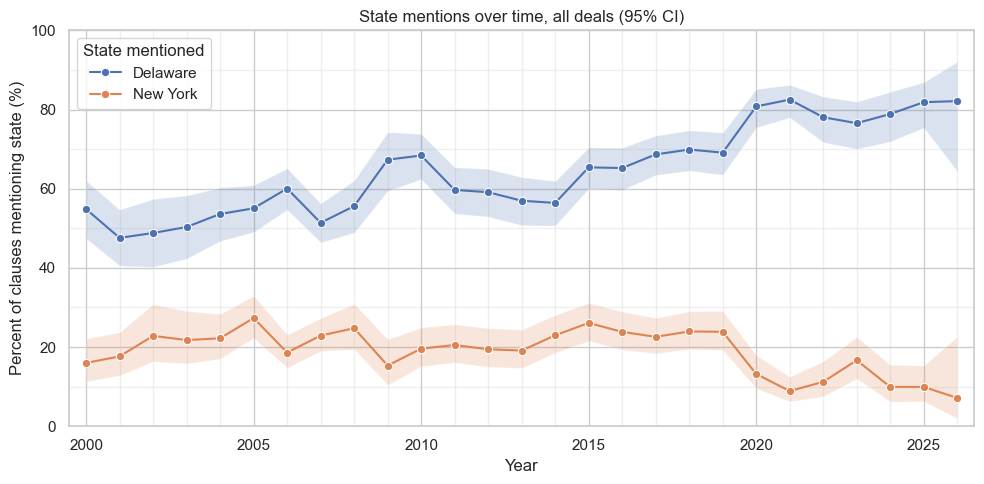

In [271]:
# Build one row per clause-state outcome and year
long_df = (
    df.dropna(subset=["year"])
      .assign(year=lambda d: d["year"].astype(int))
      .melt(
          id_vars=["year"],
          value_vars=["mentions_delaware", "mentions_new_york"],
          var_name="state",
          value_name="y",
      )
)

# Aggregate yearly successes (k) and sample sizes (n)
plot_df = (
    long_df.groupby(["year", "state"], as_index=False)
           .agg(k=("y", "sum"), n=("y", "size"))
)

lo, hi = wilson_ci(plot_df["k"], plot_df["n"])
plot_df["pct"] = (plot_df["k"] / plot_df["n"]) * 100
plot_df["lo"]  = lo * 100
plot_df["hi"]  = hi * 100

plot_df["state"] = plot_df["state"].map({
    "mentions_delaware": "Delaware",
    "mentions_new_york": "New York",
})

# Plot yearly rates with 95% Wilson confidence bands
plt.figure(figsize=(10, 5))
sns.lineplot(data=plot_df, x="year", y="pct", hue="state", marker="o")

ax = plt.gca()
for state, sdf in plot_df.sort_values("year").groupby("state"):
    ax.fill_between(sdf["year"].to_numpy(), sdf["lo"].to_numpy(), sdf["hi"].to_numpy(), alpha=0.2)

ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
plt.xlabel("Year")
plt.ylabel("Percent of clauses mentioning state (%)")
plt.title("State mentions over time, all deals (95% CI)")
plt.ylim(0, 100)
x_min, x_max = plot_df["year"].min(), plot_df["year"].max()
plt.xlim(x_min - 0.5, x_max + 0.5)

ax.yaxis.set_major_locator(MultipleLocator(20))
ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))

ax.grid(True, which="major", axis="both")
ax.grid(True, which="minor", axis="both", alpha=0.3)

ax.legend(title="State mentioned")

plt.tight_layout()
plt.show()


#### 3. Single-state selections over time (all deals)
- **Chart:** How often governing law clauses contain _only_ New York or Delaware..  
- **Limits:** Multi-state or more complex formulations are excluded from the numerator.

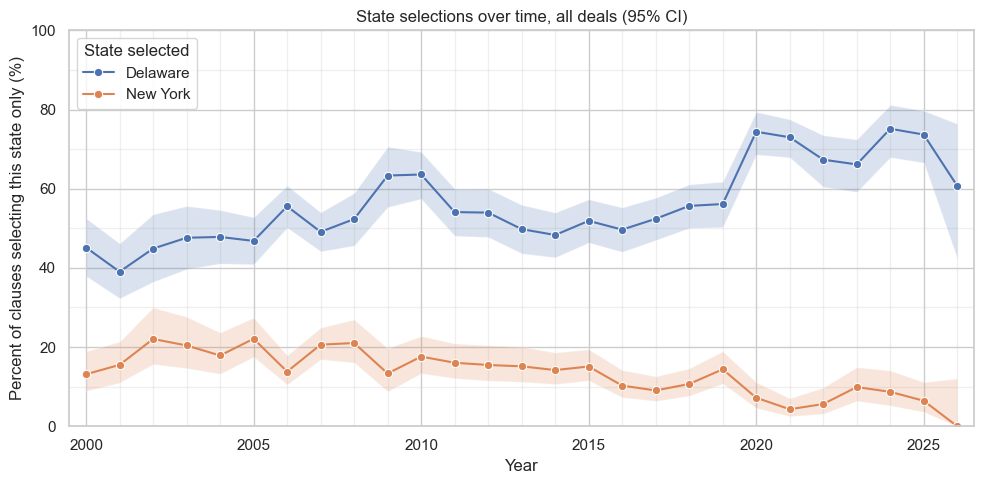

In [272]:
# Build one row per clause-state outcome and year
long_df = (
    df.dropna(subset=["year"])
      .assign(year=lambda d: d["year"].astype(int))
      .melt(
          id_vars=["year"],
          value_vars=["only_delaware", "only_new_york"],
          var_name="state",
          value_name="y",
      )
)

# Aggregate yearly successes (k) and sample sizes (n)
plot_df = (
    long_df.groupby(["year", "state"], as_index=False)
           .agg(k=("y", "sum"), n=("y", "size"))
)

lo, hi = wilson_ci(plot_df["k"], plot_df["n"])
plot_df["pct"] = (plot_df["k"] / plot_df["n"]) * 100
plot_df["lo"]  = lo * 100
plot_df["hi"]  = hi * 100

plot_df["state"] = plot_df["state"].map({
    "only_delaware": "Delaware",
    "only_new_york": "New York",
})

# Plot yearly rates with 95% Wilson confidence bands
plt.figure(figsize=(10, 5))
sns.lineplot(data=plot_df, x="year", y="pct", hue="state", marker="o")

ax = plt.gca()
for state, sdf in plot_df.sort_values("year").groupby("state"):
    ax.fill_between(sdf["year"].to_numpy(), sdf["lo"].to_numpy(), sdf["hi"].to_numpy(), alpha=0.2)

ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
plt.xlabel("Year")
plt.ylabel("Percent of clauses selecting this state only (%)")
plt.title("State selections over time, all deals (95% CI)")
plt.ylim(0, 100)
x_min, x_max = plot_df["year"].min(), plot_df["year"].max()
plt.xlim(x_min - 0.5, x_max + 0.5)

ax.yaxis.set_major_locator(MultipleLocator(20))
ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))

ax.grid(True, which="major", axis="both")
ax.grid(True, which="minor", axis="both", alpha=0.3)

ax.legend(title="State selected")

plt.tight_layout()
plt.show()


#### 4. Single-state selections over time (mergers only)

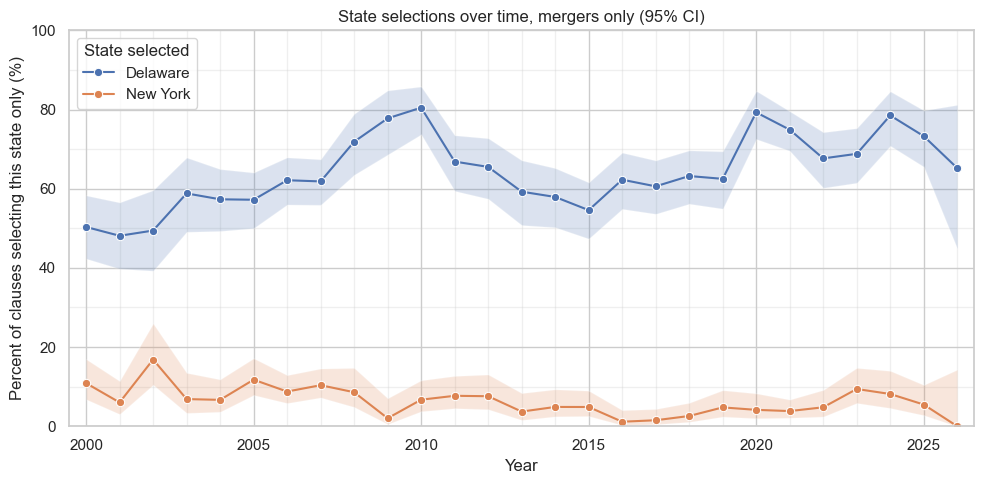

In [273]:
# Build one row per clause-state outcome and year
long_df = (
    df.query('deal_type == "Merger"')
      .dropna(subset=["year"])
      .assign(year=lambda d: d["year"].astype(int))
      .melt(
          id_vars=["year"],
          value_vars=["only_delaware", "only_new_york"],
          var_name="state",
          value_name="y",
      )
)

# Aggregate yearly successes (k) and sample sizes (n)
plot_df = (
    long_df.groupby(["year", "state"], as_index=False)
           .agg(k=("y", "sum"), n=("y", "size"))
)

lo, hi = wilson_ci(plot_df["k"], plot_df["n"])
plot_df["pct"] = (plot_df["k"] / plot_df["n"]) * 100
plot_df["lo"]  = lo * 100
plot_df["hi"]  = hi * 100

plot_df["state"] = plot_df["state"].map({
    "only_delaware": "Delaware",
    "only_new_york": "New York",
})

# Plot yearly rates with 95% Wilson confidence bands
plt.figure(figsize=(10, 5))
sns.lineplot(data=plot_df, x="year", y="pct", hue="state", marker="o")

ax = plt.gca()
for state, sdf in plot_df.sort_values("year").groupby("state"):
    ax.fill_between(sdf["year"].to_numpy(), sdf["lo"].to_numpy(), sdf["hi"].to_numpy(), alpha=0.2)

ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
plt.xlabel("Year")
plt.ylabel("Percent of clauses selecting this state only (%)")
plt.title("State selections over time, mergers only (95% CI)")
plt.ylim(0, 100)
x_min, x_max = plot_df["year"].min(), plot_df["year"].max()
plt.xlim(x_min - 0.5, x_max + 0.5)

ax.yaxis.set_major_locator(MultipleLocator(20))
ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))

ax.grid(True, which="major", axis="both")
ax.grid(True, which="minor", axis="both", alpha=0.3)

ax.legend(title="State selected")

plt.tight_layout()
plt.show()


#### 5. 100% Stacked jurisdictions by time

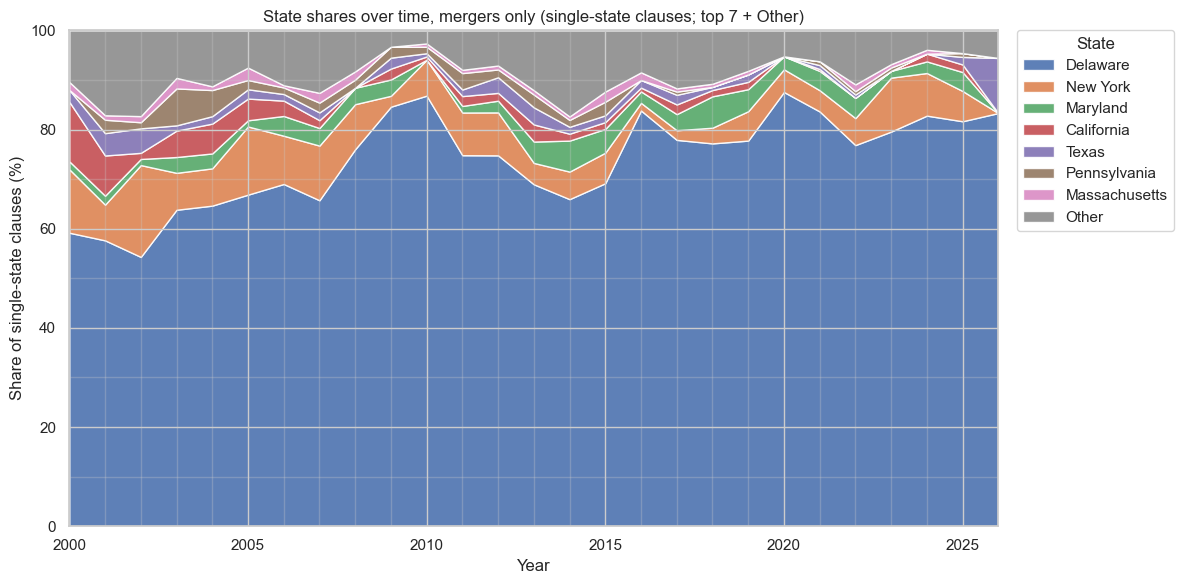

In [274]:
# Keep only mergers with exactly one selected state
plot_base = (
    df.query('deal_type == "Merger"')
      .dropna(subset=["year", "states"])
      .loc[
          lambda d: d["states"].apply(
              lambda xs: isinstance(xs, list) and len(xs) == 1 and xs[0] not in [None, "", "N/A"]
          )
      ]
      .assign(
          year=lambda d: d["year"].astype(int),
          state=lambda d: d["states"].str[0],
      )
      .copy()
)

if plot_base.empty:
    raise RuntimeError("No merger rows found with exactly one valid state in `states`.")

# Top 10 states overall; everything else becomes Other
top_states = plot_base["state"].value_counts().head(7).index.tolist()
plot_base["state_plot"] = np.where(plot_base["state"].isin(top_states), plot_base["state"], "Other")

# Count by year/state bucket, then convert to within-year shares
plot_df = (
    plot_base.groupby(["year", "state_plot"], as_index=False)
             .size()
             .rename(columns={"size": "n"})
)

plot_df["share"] = (
    plot_df["n"] / plot_df.groupby("year")["n"].transform("sum") * 100
)

# Keep legend/order stable: top states by overall frequency, then Other last
state_order = top_states + (["Other"] if (plot_base["state_plot"] == "Other").any() else [])

wide = (
    plot_df.pivot(index="year", columns="state_plot", values="share")
           .reindex(columns=state_order)
           .fillna(0)
           .sort_index()
)

# Plot as a 100% stacked area chart over time
plt.figure(figsize=(12, 6))
ax = plt.gca()

x = wide.index.to_numpy()
y_arrays = [wide[col].to_numpy() for col in wide.columns]

ax.stackplot(x, y_arrays, labels=wide.columns, alpha=0.9)

ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
ax.set_xlabel("Year")
ax.set_ylabel("Share of single-state clauses (%)")
ax.set_title("State shares over time, mergers only (single-state clauses; top 7 + Other)")
ax.set_ylim(0, 100)

x_min, x_max = wide.index.min(), wide.index.max()
ax.set_xlim(x_min, x_max)

ax.yaxis.set_major_locator(MultipleLocator(20))
ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))

ax.grid(True, which="major", axis="both")
ax.grid(True, which="minor", axis="both", alpha=0.3)

ax.legend(title="State", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
ax.set_axisbelow(False)

plt.tight_layout()
plt.show()

### See how the length of governing law clauses has evolved over time

In [275]:
xml_text = (
    df["xml"]
    .fillna("")
    .str.replace(r"<[^>]+>", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
df["word_count"] = xml_text.str.split().str.len()


In [276]:
# Check for short outliers
short = df.sort_values(by='word_count', ascending=True).head(5)['xml'].tolist()

for i in short:
    print(i)
    print()
    print('#'*40)
    print()


        <text>This Agreement is subject to Swiss Law, excluding the CISG.</text>
      

########################################


        <text>This Agreement shall be governed by the laws of State of New York.</text>
      

########################################


        <text>This Agreement shall be governed by and construed in accordance with French law.</text>
      

########################################


        <text>This Agreement shall be governed by, and construed in accordance with, the Laws of Italy.</text>
      

########################################


        <text>This Agreement is governed in all respects by the laws of the State of Delaware.</text>
      

########################################



In [277]:
# Check for long outliers
long = df.sort_values(by='word_count', ascending=False).head(5)['xml'].tolist()

for i in long:
    print(i)
    print()
    print('#'*40)
    print()


        <text>(a) THIS AGREEMENT SHALL BE DEEMED TO BE MADE IN AND IN ALL RESPECTS SHALL BE INTERPRETED, CONSTRUED AND GOVERNED BY AND IN ACCORDANCE WITH THE LAW OF THE STATE OF DELAWARE WITHOUT REGARD TO THE CONFLICTS OF LAW PRINCIPLES THEREOF TO THE EXTENT THAT SUCH PRINCIPLES WOULD DIRECT A MATTER TO ANOTHER JURISDICTION. The parties hereto hereby irrevocably submit to the personal jurisdiction of the Court of Chancery of the State of Delaware or, if such Court of Chancery shall lack subject matter jurisdiction, the federal courts of the United States of America located in the County of New Castle, Delaware, solely in respect of the interpretation and enforcement of the provisions of (and any claim or cause of action arising under or relating to) this Agreement and of the documents referred to in this Agreement, and in respect of the Transactions, and hereby waive, and agree not to assert, as a defense in any action, suit or proceeding for the interpretation or enforcement hereof o

#### 1. Word count scatter over time (mergers only)
- **Chart:** Clause length spans orders of magnitudes, so we use a log scale to enable comparisons.  
- **Limits:** Word count is descriptive and does not measure legal complexity directly.

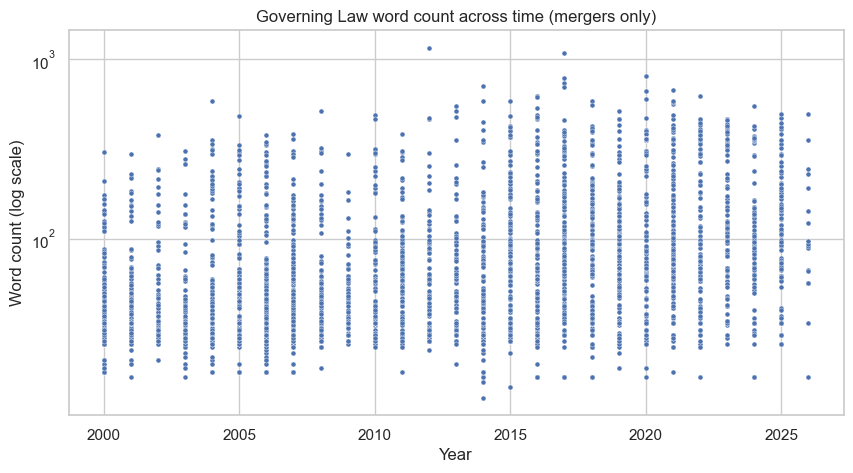

In [278]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df[(df['deal_type'] == 'Merger') & (df['gov_law_only'])], x='year', y='word_count', s=13)
plt.yscale("log")
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
plt.xlabel("Year")
plt.ylabel("Word count (log scale)")
_ = plt.title("Governing Law word count across time (mergers only)")


#### 2. Word count distribution by year (mergers only)
- **Chart:** Violin widths summarize how the full clause-length distribution changes year to year.  
- **Limits:** Years with small sample sizes can look irregular.

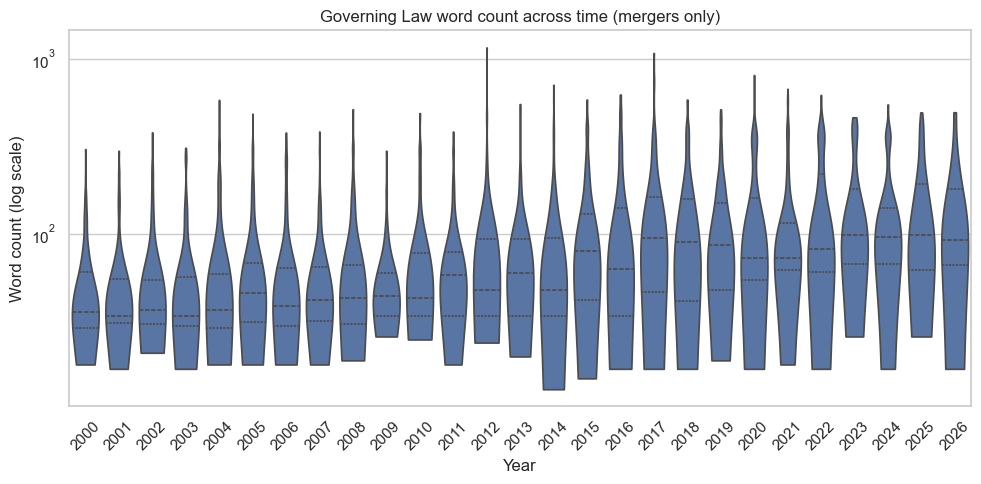

In [279]:
years = np.sort(df["year"].astype(int).unique())
df["year_cat"] = pd.Categorical(df["year"].astype(int), categories=years, ordered=True)

plt.figure(figsize=(10, 5))
ax = sns.violinplot(data=df[(df['deal_type'] == 'Merger') & (df['gov_law_only'])], x="year_cat", y="word_count", cut=0, inner="quartile", density_norm="width")
plt.yscale("log")

ax.set_xticks(np.arange(len(years)))
ax.set_xticklabels(years, rotation=45)

ax.set_xlabel("Year")
ax.set_ylabel("Word count (log scale)")
ax.set_title("Governing Law word count across time (mergers only)")
plt.tight_layout()



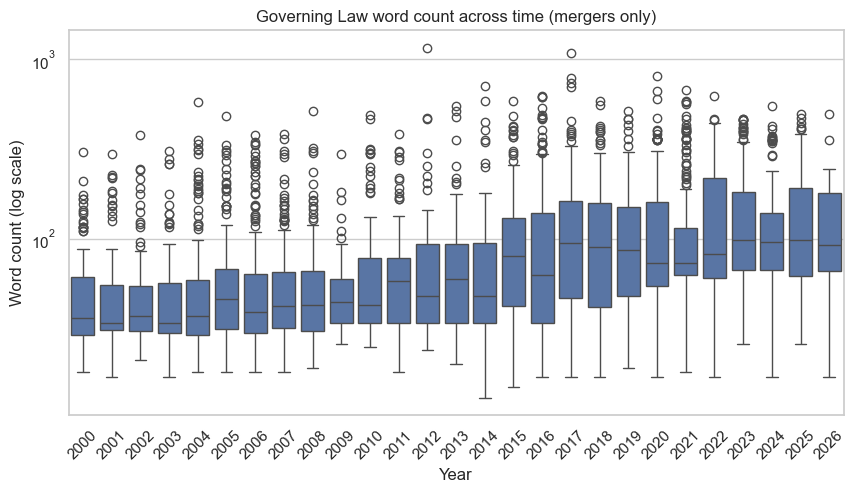

In [280]:
years = np.sort(df["year"].astype(int).unique())
df["year_cat"] = pd.Categorical(df["year"].astype(int), categories=years, ordered=True)

plt.figure(figsize=(10, 5))
ax = sns.boxplot(data=df[(df['deal_type'] == 'Merger') & (df['gov_law_only'])], x="year_cat", y="word_count")
plt.yscale("log")

ax.set_xticks(np.arange(len(years)))
ax.set_xticklabels(years, rotation=45)

ax.set_xlabel("Year")
ax.set_ylabel("Word count (log scale)")
_ = ax.set_title("Governing Law word count across time (mergers only)")

### See how choice of law and length vary with deal type

#### 1. Single-state choice by deal type
- **Chart:** Error bars represent the 95% confidence interval.  

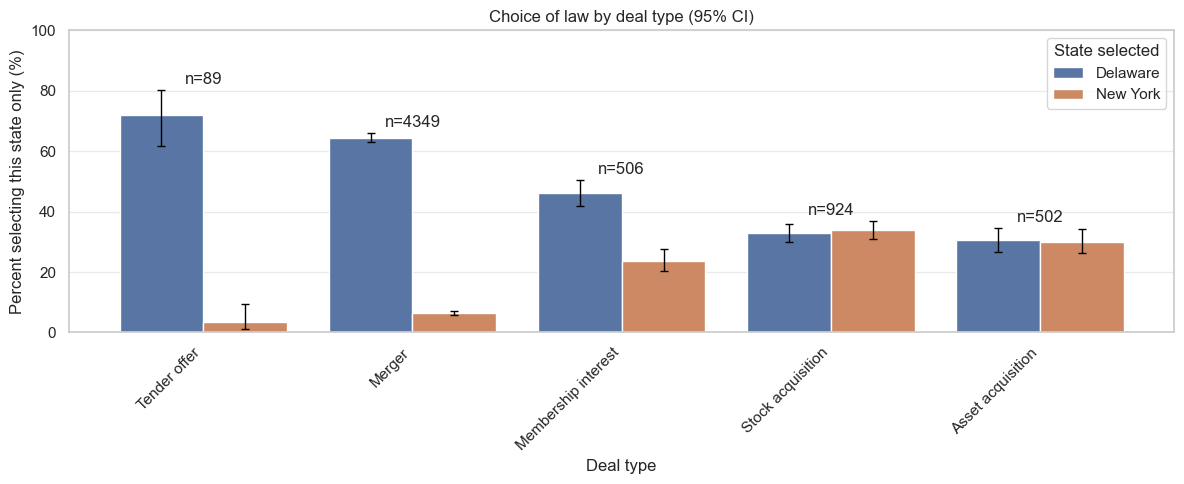

In [281]:
# Build one row per clause-state outcome and deal type
long_df = (
    df.dropna(subset=["deal_type"])
      .melt(
          id_vars=["deal_type"],
          value_vars=["only_delaware", "only_new_york"],
          var_name="state",
          value_name="y",
      )
)

# Aggregate successes (k) and sample sizes (n) by deal type and state
plot_df = (
    long_df.groupby(["deal_type", "state"], as_index=False)
           .agg(k=("y", "sum"), n=("y", "size"))
)

# Compute percentages with 95% Wilson confidence intervals
lo, hi = wilson_ci(plot_df["k"], plot_df["n"])
plot_df["pct"] = (plot_df["k"] / plot_df["n"]) * 100
plot_df["lo"]  = lo * 100
plot_df["hi"]  = hi * 100

plot_df["state"] = plot_df["state"].map({
    "only_delaware": "Delaware",
    "only_new_york": "New York",
})

# Order deal types by Delaware-only share
order = (
    plot_df.query("state == 'Delaware'")
           .sort_values("pct", ascending=False)["deal_type"]
           .tolist()
)

# Plot side-by-side bars for Delaware vs New York
plt.figure(figsize=(12, 5))
ax = sns.barplot(
    data=plot_df,
    x="deal_type",
    y="pct",
    hue="state",
    order=order,
    errorbar=None,   # Draw custom confidence intervals
)

# Add Wilson confidence intervals aligned to bar positions
for container, state in zip(ax.containers, ["Delaware", "New York"]):
    sdf = plot_df[plot_df["state"] == state].set_index("deal_type").loc[order].reset_index()
    xs = [p.get_x() + p.get_width()/2 for p in container.patches]
    y = sdf["pct"].to_numpy()
    yerr = np.vstack([y - sdf["lo"].to_numpy(), sdf["hi"].to_numpy() - y])
    ax.errorbar(xs, y, yerr=yerr, fmt="none", capsize=3, linewidth=1, ecolor="black")

# Label each deal type with n above the larger confidence interval
pad = 1.0  # Padding above the confidence interval (percentage points)
g = (plot_df.set_index(["deal_type", "state"])
              .loc[(order, ["Delaware", "New York"]), ["n", "hi"]]
              .reset_index())

xticks = ax.get_xticks()
xmap = dict(zip(order, xticks))

for dt in order:
    sub = g[g["deal_type"] == dt]
    n = int(sub["n"].iloc[0])
    y_text = float(sub["hi"].max()) + pad
    ax.text(xmap[dt], y_text, f"n={n}", ha="center", va="bottom")

ax.set_xlabel("Deal type")
ax.set_ylabel("Percent selecting this state only (%)")
ax.set_title("Choice of law by deal type (95% CI)")
ax.set_ylim(0, 100)

ax.grid(True, axis="y", which="major", alpha=0.4)

ax.legend(title="State selected")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


#### 2. Word count by deal type

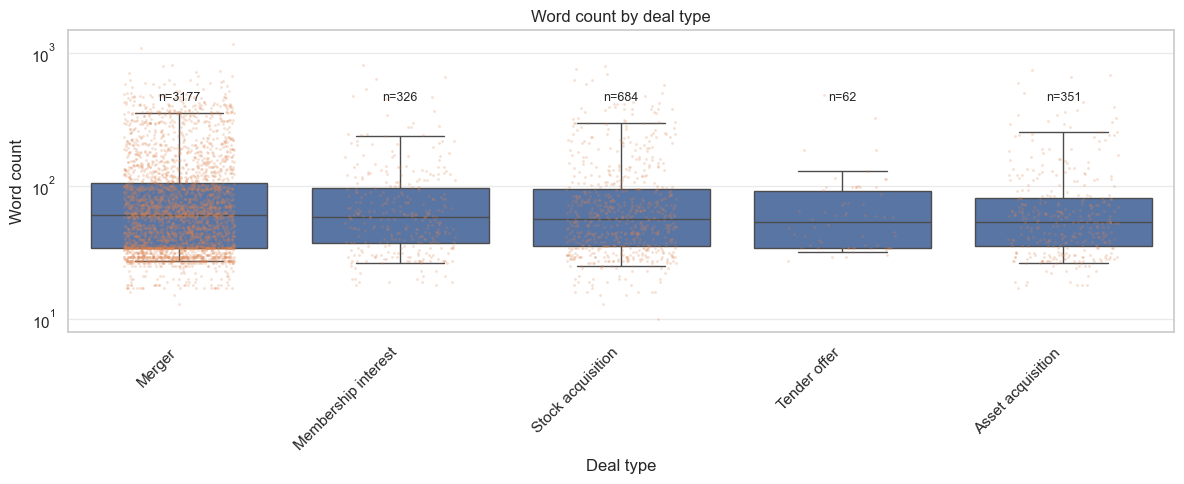

In [285]:
# Plot word-count distribution by deal type
plot_df = df[df['gov_law_only']].dropna(subset=["deal_type", "word_count"]).copy()

# Order deal types by median word count (descending)
order = (
    plot_df.groupby("deal_type")["word_count"]
           .median()
           .sort_values(ascending=False)
           .index
           .tolist()
)

plt.figure(figsize=(12, 5))
ax = sns.boxplot(
    data=plot_df,
    x="deal_type",
    y="word_count",
    order=order,
    showfliers=False,      # Hide outliers for readability
    whis=(5, 95),          # Use 5th-95th percentile whiskers
)

# Overlay jittered points to show distribution texture
sns.stripplot(
    data=plot_df,
    x="deal_type",
    y="word_count",
    order=order,
    size=2,
    alpha=0.25,
    jitter=0.25,
    ax=ax,
)

# Label each deal type with n
counts = plot_df["deal_type"].value_counts().reindex(order)
ymax = plot_df["word_count"].quantile(0.975)
for i, dt in enumerate(order):
    ax.text(i, ymax*1.02, f"n={int(counts.loc[dt])}", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Deal type")
ax.set_ylabel("Word count")
ax.set_title("Word count by deal type")
ax.grid(True, axis="y", which="major", alpha=0.4)
ax.set_yscale("log")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Bayesian comparison: Is Delaware more common than New York by deal type?

Estimate posterior distributions for `P(only_delaware)` and `P(only_new_york)` with a Beta(1,1) prior, then compute `Pr(p_delaware > p_new_york)` for each deal type.

**Chart:** Values near 100% indicate strong posterior support that Delaware-only is more common than New York-only for that deal type.  
**Limits:** This compares single-state selections only and assumes independent Bernoulli observations within deal type.

,deal_type,n,Pr(Delaware > New York),E[p_delaware],E[p_new_york]
0,Membership interest,506,100.00,46.06,23.82
1,Merger,4349,100.00,64.51,6.39
2,Tender offer,89,100.00,71.39,4.36
3,Asset acquisition,502,55.34,30.54,30.17
4,Stock acquisition,924,31.58,32.83,33.91


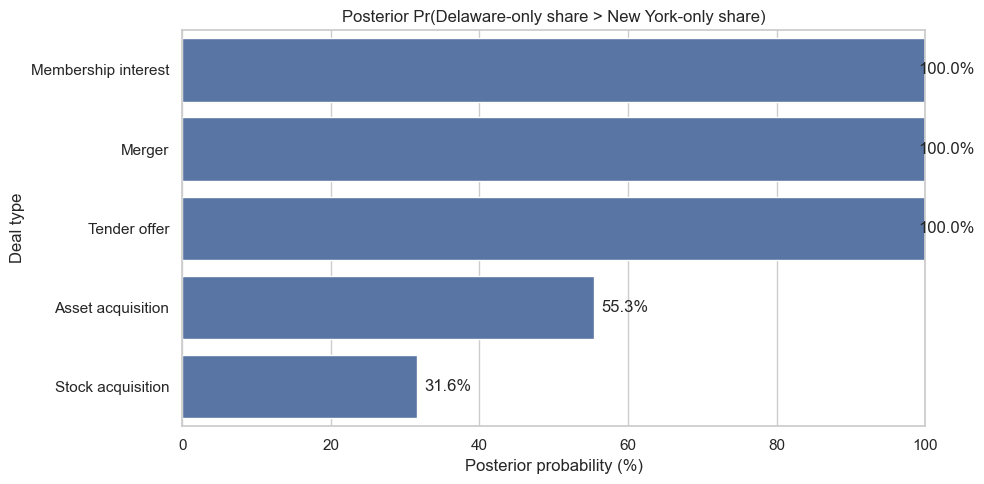

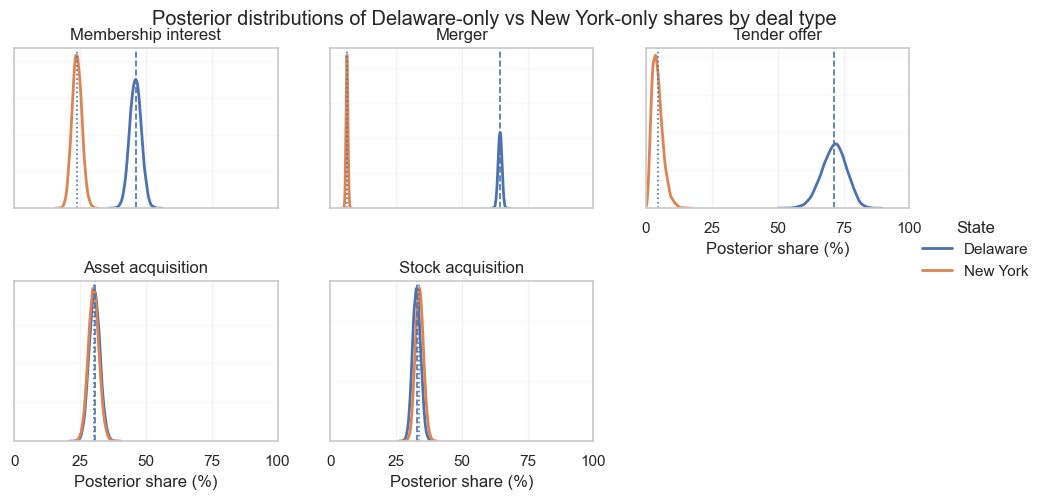

In [286]:
rng = np.random.default_rng(7)
draws = 20_000

rows = []
posterior_rows = []  # Store posterior draws for facet plotting

for deal_type, g in df.dropna(subset=["deal_type"]).groupby("deal_type"):
    n = len(g)
    k_delaware = int(g["only_delaware"].sum())
    k_new_york = int(g["only_new_york"].sum())

    # Use Beta(1,1) prior -> Beta(1+k, 1+n-k) posterior.
    delaware_draws = rng.beta(1 + k_delaware, 1 + n - k_delaware, size=draws)
    new_york_draws = rng.beta(1 + k_new_york, 1 + n - k_new_york, size=draws)

    # Store summary metrics.
    rows.append({
        "deal_type": deal_type,
        "n": n,
        "Pr(Delaware > New York)": float((delaware_draws > new_york_draws).mean()),
        "E[p_delaware]": float(delaware_draws.mean()),
        "E[p_new_york]": float(new_york_draws.mean()),
        "delaware_lo": float(np.quantile(delaware_draws, 0.025)),
        "delaware_hi": float(np.quantile(delaware_draws, 0.975)),
        "new_york_lo": float(np.quantile(new_york_draws, 0.025)),
        "new_york_hi": float(np.quantile(new_york_draws, 0.975)),
    })

    # Store posterior draws as percentages for plotting
    posterior_rows.append(pd.DataFrame({
        "deal_type": deal_type,
        "state": "Delaware",
        "p": delaware_draws * 100
    }))
    posterior_rows.append(pd.DataFrame({
        "deal_type": deal_type,
        "state": "New York",
        "p": new_york_draws * 100
    }))

bayes_df = pd.DataFrame(rows).sort_values("Pr(Delaware > New York)", ascending=False).reset_index(drop=True)
posterior_df = pd.concat(posterior_rows, ignore_index=True)

# Convert selected summary columns to percentages
pct_cols = ["Pr(Delaware > New York)", "E[p_delaware]", "E[p_new_york]",
            "delaware_lo", "delaware_hi", "new_york_lo", "new_york_hi"]
bayes_df[pct_cols] = bayes_df[pct_cols] * 100

# Keep facet order consistent with the summary table
deal_order = bayes_df["deal_type"].tolist()
posterior_df["deal_type"] = pd.Categorical(posterior_df["deal_type"], categories=deal_order, ordered=True)

display(
    bayes_df[["deal_type", "n", "Pr(Delaware > New York)", "E[p_delaware]", "E[p_new_york]"]].round(2)
)

# Plot posterior probability bar chart
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=bayes_df, x="Pr(Delaware > New York)", y="deal_type")
ax.set_xlabel("Posterior probability (%)")
ax.set_ylabel("Deal type")
ax.set_title("Posterior Pr(Delaware-only share > New York-only share)")
ax.set_xlim(0, 100)

for p in ax.patches:
    w = p.get_width()
    ax.text(min(w + 1, 99), p.get_y() + p.get_height() / 2, f"{w:.1f}%", va="center")

plt.tight_layout()
plt.show()

g = sns.FacetGrid(
    posterior_df,
    col="deal_type",
    col_wrap=3,          # Set facet columns based on the number of deal types
    hue="state",
    sharex=True,
    sharey=False,
    height=2.4,
    aspect=1.35,
    margin_titles=False,
    despine=False,
)

g.map_dataframe(
    sns.kdeplot,
    x="p",
    fill=False,
    common_norm=False,
    bw_adjust=1.1,
    clip=(0, 100),
    linewidth=2
)

# Simplify facet titles
g.set_titles("{col_name}")

# Add posterior means as vertical lines
for ax, deal_type in zip(g.axes.flat, deal_order):
    sub = bayes_df.loc[bayes_df["deal_type"] == deal_type].iloc[0]
    ax.axvline(sub["E[p_delaware]"], linestyle="--", linewidth=1.2)
    ax.axvline(sub["E[p_new_york]"], linestyle=":", linewidth=1.2)

    # Format axes
    ax.set_xlim(0, 100)
    ax.grid(axis="x", alpha=0.25)
    ax.grid(axis="y", alpha=0.10)

    # Use consistent x ticks
    ax.set_xticks([0, 25, 50, 75, 100])

    # Hide y-axis density tick labels
    ax.set_yticklabels([])

g.add_legend(title="State")

# Set shared labels and title.
g.set_xlabels("Posterior share (%)")
g.set_ylabels("")

# Use subplots_adjust for dense FacetGrid layouts
g.fig.subplots_adjust(
    top=0.90,
    bottom=0.08,
    left=0.06,
    right=0.88,   # Leave room for the legend
    hspace=0.45,
    wspace=0.20
)
g.fig.suptitle("Posterior distributions of Delaware-only vs New York-only shares by deal type")

plt.show()


### Concentration of governing-law selections over time (mergers only)

Compute annual concentration metrics on clauses with a single identified jurisdiction: Herfindahl index (HHI), Shannon entropy, and effective number of states (`1/HHI`).

#### 1. Straight HHI, no statistical tricks

,year,n,hhi,entropy,effective_states
17,2017,154,0.611,1.151,1.638
18,2018,158,0.603,1.109,1.660
19,2019,135,0.612,1.042,1.635
20,2020,153,0.770,0.616,1.298
21,2021,257,0.704,0.830,1.421
22,2022,147,0.597,1.123,1.675
23,2023,147,0.646,0.870,1.547
24,2024,128,0.694,0.737,1.440
25,2025,131,0.673,0.838,1.485
26,2026,18,0.710,0.557,1.409


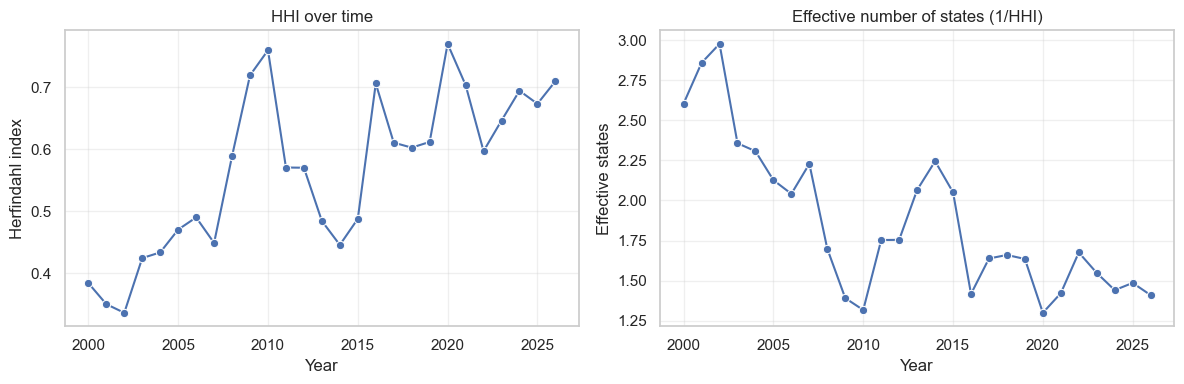

In [287]:
single_state_df = df[df["states"].apply(lambda xs: isinstance(xs, list) and len(xs) == 1 and xs[0] != "N/A")].copy()
single_state_df["state"] = single_state_df["states"].str[0]
single_state_df["year"] = single_state_df["year"].astype(int)
single_state_df = single_state_df[single_state_df['deal_type'] == 'Merger']

concentration_rows = []
for year, g in single_state_df.groupby("year"):
    shares = g["state"].value_counts(normalize=True)
    hhi = float((shares ** 2).sum())
    entropy = float(-(shares * np.log(shares)).sum())
    concentration_rows.append({
        "year": year,
        "n": int(len(g)),
        "hhi": hhi,
        "entropy": entropy,
        "effective_states": float(1 / hhi),
    })

conc_df = pd.DataFrame(concentration_rows).sort_values("year")
display(conc_df.round(3).tail(10))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

sns.lineplot(data=conc_df, x="year", y="hhi", marker="o", ax=axes[0])
axes[0].set_title("HHI over time")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Herfindahl index")

sns.lineplot(data=conc_df, x="year", y="effective_states", marker="o", ax=axes[1])
axes[1].set_title("Effective number of states (1/HHI)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Effective states")

for ax in axes:
    ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
    ax.grid(True, axis="both", alpha=0.3)

plt.tight_layout()
plt.show()


#### 2. HHI estimated using a Bayesian Dirichlet posterior, with a 95% credible interval

,year,n,hhi,hhi_lo,hhi_hi,entropy,entropy_lo,entropy_hi,effective_states,effective_states_lo,effective_states_hi
17,2017,154,0.371,0.294,0.451,2.027,1.764,2.292,2.728,2.216,3.399
18,2018,158,0.370,0.294,0.450,2.000,1.739,2.256,2.738,2.223,3.397
19,2019,135,0.350,0.272,0.434,2.060,1.784,2.331,2.897,2.306,3.673
20,2020,153,0.462,0.379,0.550,1.709,1.436,1.976,2.183,1.819,2.637
21,2021,257,0.511,0.441,0.581,1.539,1.325,1.757,1.968,1.720,2.270
22,2022,147,0.355,0.279,0.436,2.051,1.788,2.313,2.851,2.295,3.588
23,2023,147,0.383,0.307,0.465,1.908,1.643,2.170,2.641,2.150,3.259
24,2024,128,0.385,0.302,0.471,1.923,1.647,2.203,2.631,2.122,3.311
25,2025,131,0.378,0.297,0.465,1.963,1.684,2.236,2.680,2.152,3.363
26,2026,18,0.088,0.053,0.145,3.118,2.824,3.357,12.124,6.877,18.855


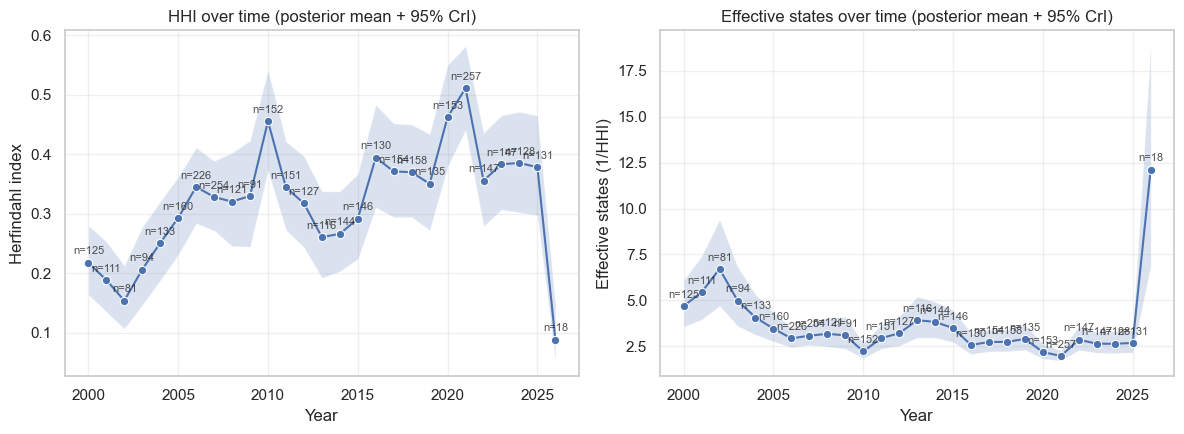

In [288]:
single_state_df = df[df["states"].apply(lambda xs: isinstance(xs, list) and len(xs) == 1 and xs[0] != "N/A")].copy()
single_state_df["state"] = single_state_df["states"].str[0]
single_state_df["year"] = single_state_df["year"].astype(int)
single_state_df = single_state_df[single_state_df["deal_type"] == "Merger"].copy()

rng = np.random.default_rng(7)
draws = 20_000
alpha_prior = 1.0   # Symmetric Dirichlet prior (Laplace smoothing)

# Use a fixed state universe across years for comparability
state_universe = sorted(single_state_df["state"].dropna().unique().tolist())

rows = []

for year, g in single_state_df.groupby("year"):
    n = len(g)
    if n == 0:
        continue

    counts = g["state"].value_counts()

    # Align counts to the common state universe
    c = counts.reindex(state_universe, fill_value=0).to_numpy(dtype=float)
    alpha = np.full_like(c, fill_value=alpha_prior, dtype=float)

    # Draw posterior samples of the state-share vector p
    # Shape: (draws, K).
    p_draws = rng.dirichlet(alpha + c, size=draws)

    # Draw posterior samples of concentration metrics
    hhi_draws = np.sum(p_draws ** 2, axis=1)

    # Guard against log(0) from numerical underflow
    p_safe = np.clip(p_draws, 1e-15, 1.0)
    entropy_draws = -np.sum(p_safe * np.log(p_safe), axis=1)

    effective_draws = 1.0 / hhi_draws

    rows.append({
        "year": int(year),
        "n": int(n),

        # Store posterior summaries (mean and 95% credible interval)
        "hhi": float(hhi_draws.mean()),
        "hhi_lo": float(np.quantile(hhi_draws, 0.025)),
        "hhi_hi": float(np.quantile(hhi_draws, 0.975)),

        "entropy": float(entropy_draws.mean()),
        "entropy_lo": float(np.quantile(entropy_draws, 0.025)),
        "entropy_hi": float(np.quantile(entropy_draws, 0.975)),

        "effective_states": float(effective_draws.mean()),
        "effective_states_lo": float(np.quantile(effective_draws, 0.025)),
        "effective_states_hi": float(np.quantile(effective_draws, 0.975)),
    })

conc_df = pd.DataFrame(rows).sort_values("year").reset_index(drop=True)

display(conc_df.round(3).tail(10))

# Plot posterior concentration metrics
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)

# Plot HHI posterior mean with 95% credible interval
sns.lineplot(data=conc_df, x="year", y="hhi", marker="o", ax=axes[0])
axes[0].fill_between(
    conc_df["year"].to_numpy(),
    conc_df["hhi_lo"].to_numpy(),
    conc_df["hhi_hi"].to_numpy(),
    alpha=0.20
)
axes[0].set_title("HHI over time (posterior mean + 95% CrI)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Herfindahl index")

# Plot effective states posterior mean with 95% credible interval
sns.lineplot(data=conc_df, x="year", y="effective_states", marker="o", ax=axes[1])
axes[1].fill_between(
    conc_df["year"].to_numpy(),
    conc_df["effective_states_lo"].to_numpy(),
    conc_df["effective_states_hi"].to_numpy(),
    alpha=0.20
)
axes[1].set_title("Effective states over time (posterior mean + 95% CrI)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Effective states (1/HHI)")

# Annotate points with n to contextualize uncertainty
for ax, ycol in zip(axes, ["hhi", "effective_states"]):
    for _, r in conc_df.iterrows():
        ax.annotate(
            f"n={int(r['n'])}",
            (r["year"], r[ycol]),
            textcoords="offset points",
            xytext=(0, 6),
            ha="center",
            fontsize=8,
            alpha=0.8
        )

for ax in axes:
    ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
    ax.grid(True, axis="both", alpha=0.3)

plt.tight_layout()
plt.show()
